In [97]:
import numpy as np
import pandas as pd
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
# load tsv with eval data
save_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(save_dir, 'real_parcellation_cerebellum.tsv')
D = pd.read_csv(saved_file, sep='\t')

In [99]:
# defube metrics to plot
metrics = ['random','variance','inverse_trace_mc']
D = D[D['metric'].isin(metrics)]

In [100]:
custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

C:\Users\barafat\AppData\Local\Temp\ipykernel_3964\1203516180.py:7: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


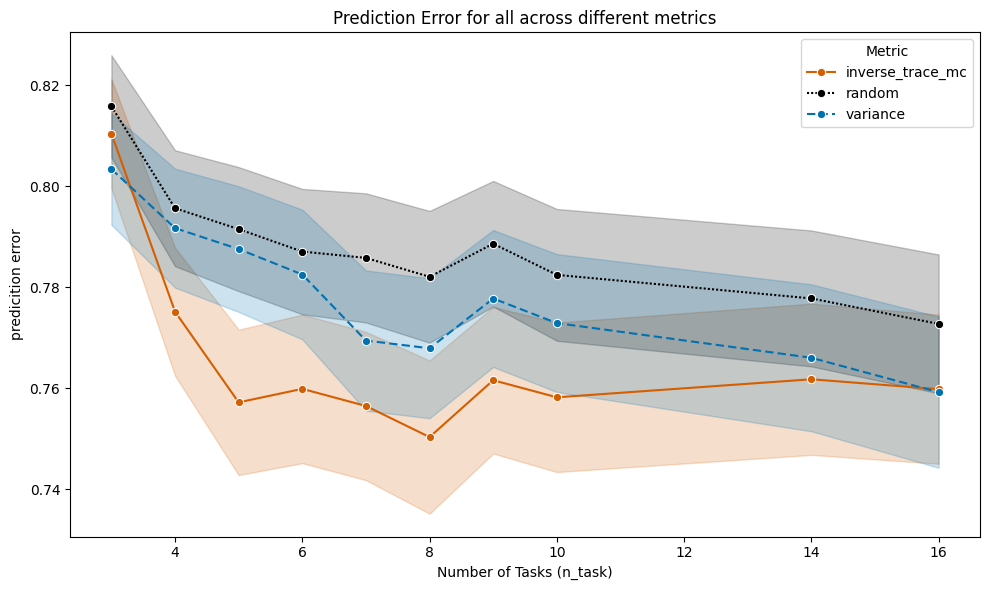

In [101]:
# check unique ROIs
rois = D['roi'].unique()
for roi in rois:
    df_roi = D[D['roi'] == roi]

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_roi,
        x="n_task",
        y="avg_cos_err_per_subject",
        hue="metric",
        style="metric",
        errorbar='se',
        palette=custom_palette,
        dashes=custom_dashes,
        markers='o'
    )

    plt.xlabel("Number of Tasks (n_task)")
    plt.ylabel("predicition error")
    plt.title(f"Prediction Error for {roi} across different metrics")
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()